In [1]:
from sklearn.model_selection import train_test_split

In [2]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
gdf = gpd.read_file(data_path)

In [3]:
gdf 

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,eccentricity,solidity,mean_intensity,perimeter,compactness,shape_index,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,35863.728720,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.401669,1.0,63.165356,1331.480192,0.254212,1.983362,0.900242,0.437163,0.817446,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,7067.391800,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.859606,1.0,75.517822,445.486569,0.447507,1.494859,1.759124,0.730754,0.714141,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12736.830326,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.581758,1.0,57.324478,514.273064,0.605179,1.285459,1.150156,0.535901,0.780932,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,20192.843054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.609624,1.0,93.691475,578.345347,0.758635,1.148110,1.465598,0.735386,0.693349,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5222.807786,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.571195,1.0,32.228394,459.390754,0.310992,1.793186,1.024244,0.401829,0.845566,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1545.971923,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.192704,1.0,28.864557,242.379949,0.330688,1.738965,0.838901,0.354046,0.859828,"POLYGON ((-75.123 3.80901, -75.12297 3.809, -7..."
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026303,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.595796,1.0,0.083861,11.946954,0.002316,20.780311,0.823263,0.044593,0.996933,"POLYGON ((-75.12391 3.81075, -75.1239 3.81076,..."
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10654.442452,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.225197,1.0,27.726738,1277.998650,0.081975,3.492690,1.323494,0.527732,0.798940,"POLYGON ((-75.12278 3.8104, -75.12282 3.81044,..."
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5196.479151,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.896007,1.0,44.873081,376.043545,0.461788,1.471562,1.437832,0.682919,0.724081,"POLYGON ((-75.12367 3.81079, -75.12357 3.81077..."


In [4]:
gdf.columns

Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var',
       'b_mean', 'b_median', 'b_std', 'b_var', 'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index',
       'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'geometry'],
      dtype='object')

In [5]:
def count_na(gdf):
       features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
              'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']
       na_count = gdf[features].isna().sum()
       print(f"Number of NA values in 'features' column: {na_count}")
       return na_count

In [6]:
count_na(gdf)

Number of NA values in 'features' column: r_mean                35
r_median              35
r_std                 35
r_var                 35
g_mean                35
g_median              35
g_std                 35
g_var                 35
b_mean                35
b_median              35
b_var                 35
b_std                 35
eccentricity          13
solidity              13
mean_intensity        13
perimeter              0
compactness            0
shape_index            0
area                   0
glcm_contrast         13
glcm_dissimilarity    13
glcm_homogeneity      13
dtype: int64


r_mean                35
r_median              35
r_std                 35
r_var                 35
g_mean                35
g_median              35
g_std                 35
g_var                 35
b_mean                35
b_median              35
b_var                 35
b_std                 35
eccentricity          13
solidity              13
mean_intensity        13
perimeter              0
compactness            0
shape_index            0
area                   0
glcm_contrast         13
glcm_dissimilarity    13
glcm_homogeneity      13
dtype: int64

In [7]:
gdf = gdf.dropna(subset=['r_mean'])

In [8]:
count_na(gdf)

Number of NA values in 'features' column: r_mean                0
r_median              0
r_std                 0
r_var                 0
g_mean                0
g_median              0
g_std                 0
g_var                 0
b_mean                0
b_median              0
b_var                 0
b_std                 0
eccentricity          0
solidity              0
mean_intensity        0
perimeter             0
compactness           0
shape_index           0
area                  0
glcm_contrast         0
glcm_dissimilarity    0
glcm_homogeneity      0
dtype: int64


r_mean                0
r_median              0
r_std                 0
r_var                 0
g_mean                0
g_median              0
g_std                 0
g_var                 0
b_mean                0
b_median              0
b_var                 0
b_std                 0
eccentricity          0
solidity              0
mean_intensity        0
perimeter             0
compactness           0
shape_index           0
area                  0
glcm_contrast         0
glcm_dissimilarity    0
glcm_homogeneity      0
dtype: int64

In [9]:
print(gdf['CODIGO'].value_counts())

CODIGO
0       665
231     316
311     157
333     144
112     138
233     125
232      64
313      58
22       57
21       42
122      34
511      23
111      17
312      17
512      14
323      14
3212     13
32       10
331       6
334       4
121       4
3211      3
513       3
31        1
Name: count, dtype: int64


/home/krschap/Jupyter/ubs/ml/mlproject1/landcoverclassification/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: xlabel='CODIGO_GROUP_2'>

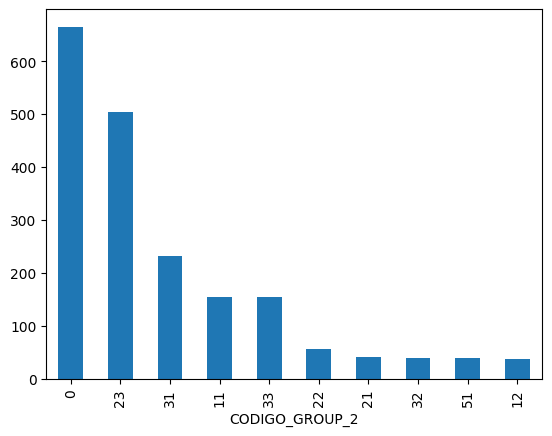

In [10]:
gdf['CODIGO_GROUP_2'] = gdf['CODIGO'].astype(str).str[:2]
gdf['CODIGO_GROUP_2'].value_counts().plot(kind='bar')

/home/krschap/Jupyter/ubs/ml/mlproject1/landcoverclassification/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: xlabel='CODIGO_GROUP_1'>

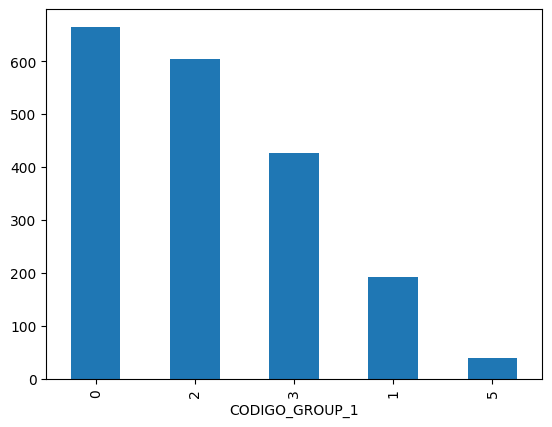

In [11]:
gdf['CODIGO_GROUP_1'] = gdf['CODIGO'].astype(str).str[:1]
gdf['CODIGO_GROUP_1'].value_counts().plot(kind='bar')

In [12]:
print(gdf['CODIGO_GROUP_2'].value_counts())

CODIGO_GROUP_2
0     665
23    505
31    233
11    155
33    154
22     57
21     42
32     40
51     40
12     38
Name: count, dtype: int64


In [13]:
gdf.to_file( os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson'), driver='GeoJSON')

### Train Split : 

We will use **stratify** , because we care about the distribution in class , just to make sure the class distribution is there in the test set as well 

train set distribution:
CODIGO_GROUP
0     532
23    404
31    186
11    124
33    123
22     46
21     34
51     32
32     32
12     30
Name: count, dtype: int64

 test distribution:
CODIGO_GROUP
0     133
23    101
31     47
33     31
11     31
22     11
12      8
51      8
32      8
21      8
Name: count, dtype: int64


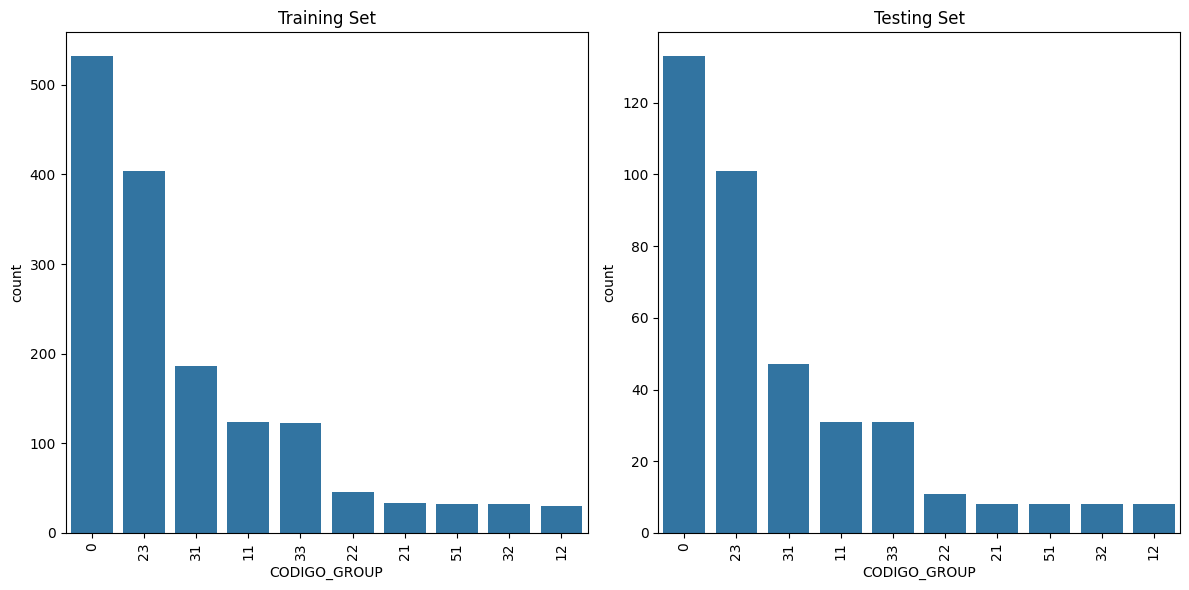

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'CODIGO_GROUP_2'
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']

train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[target])

print("train set distribution:")
print(train_gdf[target].value_counts())
print("\n test distribution:")
print(test_gdf[target].value_counts())


class_order = train_gdf[target].value_counts().index

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x=target, data=train_gdf, ax=ax[0], order=class_order)
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Training Set")

sns.countplot(x=target, data=test_gdf, ax=ax[1], order=class_order)
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Testing Set")

plt.tight_layout()
plt.show()

In [25]:
test_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))
train_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

### Spatially Stratified Sampling ?

We think as there are features spatially correlated , may be worth doing the spatial stratified sampling 

In [26]:
train_gdf[features]

,r_mean,r_median,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,...,eccentricity,solidity,mean_intensity,perimeter,compactness,shape_index,area,glcm_contrast,glcm_dissimilarity,glcm_homogeneity
89,133.839225,143.0,59.441565,3533.299693,126.577544,131.0,44.413079,1972.521559,94.983296,99.0,...,0.524276,1.0,34.753716,9534.024959,0.006733,12.186658,48704.992808,0.397998,0.165135,0.931568
396,114.827518,119.0,64.722609,4189.016147,128.036882,129.0,65.329558,4267.951132,117.081532,107.0,...,0.845097,1.0,84.670380,46.452636,0.609611,1.280777,104.680054,1.974106,0.670590,0.752872
1011,133.370506,135.0,65.046095,4230.994463,137.986885,140.0,54.743420,2996.842014,104.468104,99.0,...,0.881528,1.0,74.835030,589.182110,0.363017,1.659727,10028.035637,2.350960,0.733061,0.748659
1052,107.629064,101.0,64.980378,4222.449467,117.243460,115.0,60.172319,3620.707985,83.409694,72.0,...,0.895649,1.0,16.968140,436.707348,0.140868,2.664368,2137.877041,0.870918,0.239265,0.922603
1043,92.971167,85.0,59.308390,3517.485171,108.644764,100.0,58.166377,3383.327388,57.937371,46.0,...,0.524446,1.0,56.339184,263.186011,0.715069,1.182568,3941.519914,2.694642,0.829858,0.722434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,206.543019,236.0,58.454599,3416.940109,219.875190,247.0,53.746206,2888.654662,214.689229,249.0,...,0.783809,1.0,185.243057,20.575827,0.737560,1.164398,24.848614,3.065654,0.456815,0.863374
664,126.569305,123.0,39.021389,1522.668775,132.139372,133.0,31.927362,1019.356443,89.507846,87.0,...,0.627019,1.0,70.136940,69.244661,0.729419,1.170878,278.316951,5.164221,1.009627,0.722654
766,155.889617,157.0,50.859625,2586.701480,158.537087,157.0,41.192116,1696.790387,108.309472,92.0,...,0.428916,1.0,72.395096,62.793379,0.482874,1.439074,151.513593,3.985975,0.635734,0.802410
1630,138.203282,139.0,28.928396,836.852124,154.403635,157.0,29.309477,859.045420,104.790897,104.0,...,0.320450,1.0,68.648422,256.573661,0.555034,1.342271,2907.593573,2.154821,0.483927,0.827765


In [27]:
test_gdf[features]

,r_mean,r_median,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,...,eccentricity,solidity,mean_intensity,perimeter,compactness,shape_index,area,glcm_contrast,glcm_dissimilarity,glcm_homogeneity
189,209.842108,235.0,56.405235,3181.550505,215.251759,246.0,58.857142,3464.163108,217.176922,251.0,...,0.000000,1.000000,175.079742,16.487321,0.780406,1.131982,16.881504,3.530576,0.584974,0.829153
972,172.106141,180.0,35.726801,1276.404315,189.003401,204.0,35.625265,1269.159521,189.531541,210.0,...,0.495261,1.000000,128.606705,25.607665,0.779435,1.132687,40.673357,5.719651,0.714719,0.807466
1176,169.186053,204.0,71.615130,5128.726872,164.075252,182.0,64.124714,4111.978974,165.477083,188.0,...,0.792294,1.000000,71.321175,198.648640,0.190437,2.291526,598.014800,1.872939,0.381310,0.879386
1852,129.676551,140.0,38.733380,1500.274735,118.839881,129.0,42.042603,1767.580439,109.303006,113.0,...,0.271866,1.000000,60.813080,54.356640,0.803992,1.115255,189.037070,1.969649,0.543559,0.813324
1552,115.953335,118.0,29.588005,875.450013,141.329024,144.0,28.595190,817.684864,92.193392,91.0,...,0.958863,1.000000,46.917938,518.845698,0.271164,1.920366,5808.962255,0.875261,0.301064,0.876712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,107.434949,108.0,21.107432,445.523681,116.910780,118.0,19.493799,380.008213,67.237877,67.0,...,0.925356,0.359334,97.168274,4309.851658,0.125202,2.826148,185065.347794,0.258880,0.113666,0.951054
969,117.314502,120.0,42.670445,1820.766899,143.325772,145.0,38.494051,1481.791956,94.154177,96.0,...,0.522821,1.000000,87.586967,173.438804,0.694754,1.199732,1663.082843,2.981130,1.014076,0.639065
1391,92.411471,90.0,33.098067,1095.482064,111.421890,110.0,35.216636,1240.211483,46.496738,43.0,...,0.788938,0.974010,81.377350,124.455752,0.768540,1.140687,947.298318,4.149790,0.951553,0.703440
1752,159.629191,168.0,52.557811,2762.323524,145.039956,151.0,57.068602,3256.825280,136.702180,136.0,...,0.785495,0.780516,147.641525,101.741567,0.472270,1.455141,389.024538,3.899021,0.577580,0.835591
